# IMPORTS

In [1]:
%matplotlib widget

import lmfit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
# from ocelot.optics.wave import RadiationField, imitate_sase_dfl
import scipy.constants as spconst
from tqdm.notebook import tqdm
import xarray as xr

import fitting_tools as dfit
from XRR.XRR_2level_fit import Sample, ParrattSimulator
from TASsello import convert_E_to_I

def sci_notation(val, precision=1):
    exp = int(np.floor(np.log10(val)))
    mant = val / 10**exp
    return fr"${mant:.{precision}f} \times 10^{{{exp}}}$"

## Inputs

In [2]:
Sample.dirname_params = './sources/XRR/fit_parameters/tight_fit/'

In [3]:
def nm2eV(nm):
    return 1e9 * spconst.h * spconst.c / nm / spconst.eV

In [ ]:
samplename = 'M-220629B1_D006825_with_SiO2'
theta_ = 63.79689844922461

In [5]:
# Open measured data
sampleident = 'M_220706E1_Z_100_' 
data = xr.open_dataset(f'XFEL_exports/{sampleident}.h5', engine="h5netcdf")

## Functions

In [ ]:
hw_L3 = 932.7

# SASE params
hw_photon = 929.3     # central photon energy [eV]
sigma = 1.95 # sigma of Gaussian envelope [eV]

en_pulse = 142.5e-6      # pulse energy [J]

def simulation_model(params, x, data=None):
    sample = Sample(samplename)
    sample.set_ERES(f_ERES=params['f_ERES'].value, gamma2=params['gamma2'].value, hw_ERES=params['hw_ERES'].value)
    simulator = ParrattSimulator(sample, wls_eV=x)#np.linspace(x[0], x[-1], 100)
    R = simulator.simulate_multi_wl()
    
    thetaidx_ = np.argmin(np.abs(2*simulator.alpha - theta_))
    
    R_ = R[thetaidx_, :]
    R_interp = np.interp(x, simulator.wl_eV_list, R_)

    sase_params = lmfit.Parameters()
    sase_params.add('A', 1)
    sase_params.add('mu', hw_photon)
    sase_params.add('sigma', sigma)
    sase_params.add('offset', 0)
    ph_dens = dfit.gaussian_model(sase_params, x)
    ph_dens_norm = en_pulse * ph_dens / np.trapezoid(ph_dens, x=x)
    
    model = ph_dens_norm * R_interp
    
    # Normalization: re-scale the area above the Ledge to 1
    modidx = np.argmin(np.abs(x - hw_L3))
    model_norm = model / model[modidx]
    
    if data is None:
        return model_norm
    return model_norm - data

def iter_cb(params, iter, resid, *args, **kws):
    print(iter)

def fit_spectrum_on_model(x_signal, y_signal):
    x = x_signal
    y = y_signal
    
    params = lmfit.Parameters()
    params.add('f_ERES', 0, min=0)
    params.add('gamma2', 1.6, min=0)
    params.add('hw_ERES', 929.7, min=920, max=935)

    results = lmfit.minimize(simulation_model, params, args=(x,), kws={'data': y}, iter_cb=iter_cb)
    
    return results

In [7]:
# Normalize data
hw_max = data['energy'].max().values

norm_mes = np.trapezoid(
    data['spectrum_avg'].sel(energy=slice(hw_L3, hw_max)),
    data['energy'].sel(energy=slice(hw_L3, hw_max))
)

data['spectrum_avg_norm'] = data['spectrum_avg'] / norm_mes #data['spectrum_avg'].sel(energy=hw_L3, method='nearest')

results = fit_spectrum_on_model(data['energy'].sel(energy=slice(920, 940)).values,
                                       data['spectrum_avg_norm'].sel(energy=slice(920, 940)).values)
results.params

Simulating reflectivity:   0%|          | 0/191 [00:00<?, ?wavelength/s]

-1


Simulating reflectivity:   0%|          | 0/191 [00:00<?, ?wavelength/s]

0


Simulating reflectivity:   0%|          | 0/191 [00:00<?, ?wavelength/s]

...

Simulating reflectivity:   0%|          | 0/191 [00:00<?, ?wavelength/s]

127


Simulating reflectivity:   0%|          | 0/191 [00:00<?, ?wavelength/s]

127


name,value,standard error,relative error,initial value,min,max,vary
f_ERES,23.1671547,1.20498631,(5.20%),0.0,0.00000000,inf,True
gamma2,3.04967877,0.14047047,(4.61%),1.6,0.00000000,inf,True
hw_ERES,929.908668,0.02886777,(0.00%),929.7,920.000000,935.000000,True


In [8]:
params = results.params
results

In [9]:
colors = plt.cm.rainbow(np.linspace(0,1,5))
color = 'tab:orange'

Simulating reflectivity:   0%|          | 0/880 [00:00<?, ?wavelength/s]

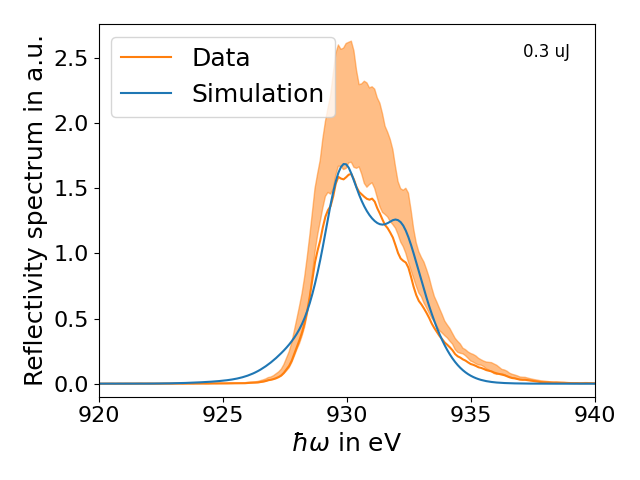

In [22]:
plt.figure()

data['spectrum_avg_norm'].plot(color = color, label='Data')
plt.fill_between(data['energy'],
                 (data['spectrum_avg'] + data['spectrum_std']) / data['spectrum_avg'].sel(energy=hw_L3, method='nearest'),
                 (data['spectrum_avg'] - data['spectrum_std']) / data['spectrum_avg'].sel(energy=hw_L3, method='nearest'),
                 color = color, alpha = 0.5,
                )

plt.plot(data['energy'].values, simulation_model(params, data['energy'].values), label='Simulation')

plt.xlabel(r'$ \hbar \omega $ in eV')
plt.ylabel(r'Reflectivity spectrum in a.u.')

plt.xlim(920, 940)
plt.ylim(-0.1)

plt.legend(loc=2)

# Add text inside the axes on the top-right corner
plt.text(0.95, 0.95, '0.3 uJ', 
         transform=plt.gca().transAxes, 
         ha='right', va='top', 
         fontsize=12, color='black', 
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.tight_layout()
plt.show()

# plt.savefig(f'imgs/XFEL_fit/3e-1uJ.png', bbox_inches='tight')

# PAPER FIGURES

In [11]:
results.params

name,value,standard error,relative error,initial value,min,max,vary
f_ERES,23.1671547,1.20498631,(5.20%),0.0,0.00000000,inf,True
gamma2,3.04967877,0.14047047,(4.61%),1.6,0.00000000,inf,True
hw_ERES,929.908668,0.02886777,(0.00%),929.7,920.000000,935.000000,True


In [ ]:
pump_energy = [0.3, 8.8, 20.1, 67.4, 142.5]

f = [0, 7.26457426, 41.6158532, 43.0294855, 23.1671540]
f_err = [0.17216364, 0.31390710, 1.10293474, 1.31731302, 1.20498648]

g2 = [0.5, 1.35207408, 3.42323525, 3.71325469, 3.04967869]
g2_err = [0.24726646, 0.06429101, 0.07767777, 0.09459290, 0.14047048]

hw = [929.7, 929.595456, 929.782532, 929.865348, 929.908668] 
hw_err = [0.07633154, 0.01803106, 0.01530342, 0.01792952, 0.02886777]

In [14]:
sampleident = [
    'M_220706E1_Z_0.3_',
    'M_220706E1_Z_10_',
    'M_220706E1_Z_25_',
    'M_220706E1_Z_50_',
    'M_220706E1_Z_100_',    
]

In [15]:
energies = np.linspace(890, 980, 1000)

In [16]:
measurement = {pe: xr.open_dataset(f'XFEL_exports/{sampleident[i]}.h5', engine='h5netcdf')
               for i, pe in enumerate(pump_energy)
              }

simulation = {}
for i, pe in enumerate(tqdm(pump_energy)):
    simulation[pe] = xr.Dataset()
    
    params = lmfit.Parameters()
    params.add('f_ERES', f[i])
    params.add('gamma2', g2[i])
    params.add('hw_ERES', hw[i])
    simulation[pe]['R_all'] = xr.DataArray(
        simulation_model(params, energies),
        coords = {'energy': energies})
    
    # Re-normalize to unitary area after L3 edge
    hw_max = min(simulation[pe].energy[-1], measurement[pe].energy[-1])

    norm_sim = np.trapezoid(
        simulation[pe]['R_all'].sel(energy=slice(hw_L3, hw_max)),
        simulation[pe]['energy'].sel(energy=slice(hw_L3, hw_max))
    )
    norm_mes = np.trapezoid(
        measurement[pe]['spectrum_avg'].sel(energy=slice(hw_L3, hw_max)),
        measurement[pe]['energy'].sel(energy=slice(hw_L3, hw_max))
    )

    simulation[pe]['R_all_renorm'] = simulation[pe]['R_all'] / norm_sim
    measurement[pe]['spectrum_avg_renorm'] = measurement[pe]['spectrum_avg'] / norm_mes
    measurement[pe]['spectrum_std_renorm'] = measurement[pe]['spectrum_std'] / norm_mes

  0%|          | 0/5 [00:00<?, ?it/s]

Simulating reflectivity:   0%|          | 0/1000 [00:00<?, ?wavelength/s]

Simulating reflectivity:   0%|          | 0/1000 [00:00<?, ?wavelength/s]

Simulating reflectivity:   0%|          | 0/1000 [00:00<?, ?wavelength/s]

Simulating reflectivity:   0%|          | 0/1000 [00:00<?, ?wavelength/s]

Simulating reflectivity:   0%|          | 0/1000 [00:00<?, ?wavelength/s]

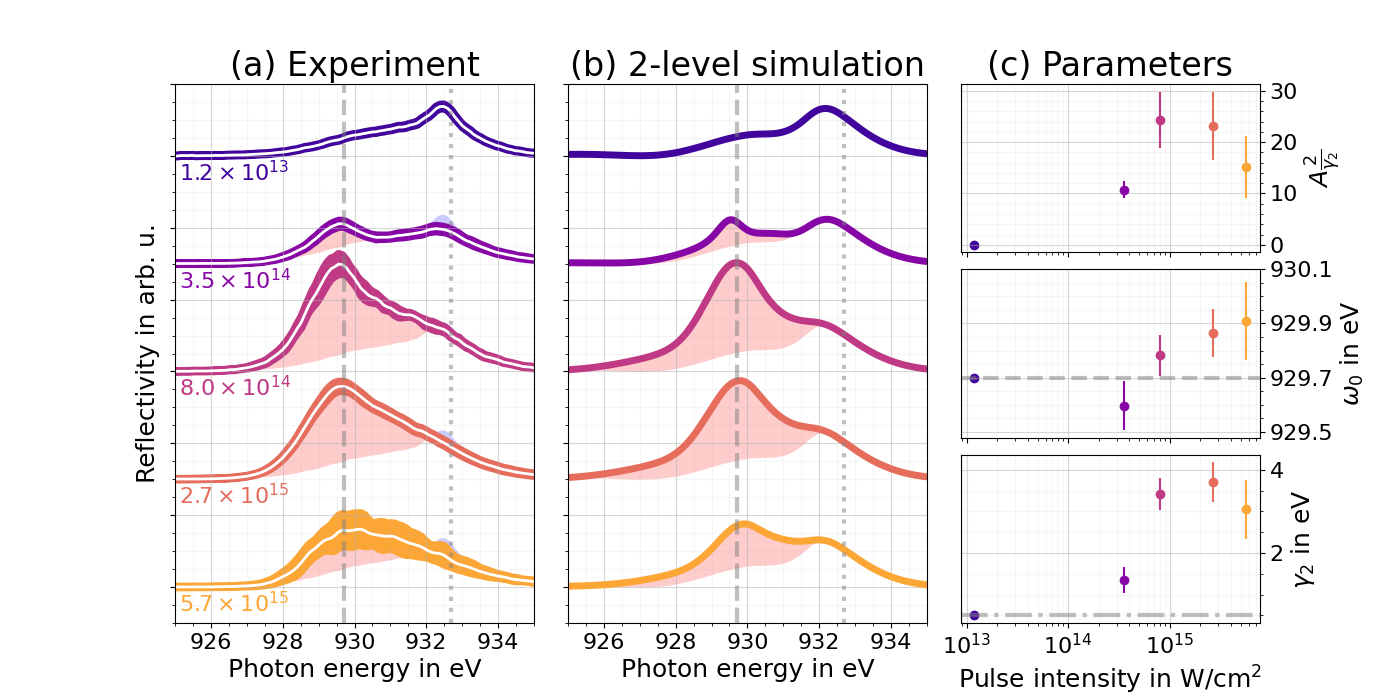

In [19]:
colors = plt.colormaps['plasma'](np.linspace(0.1, 0.8, 5))

fig = plt.figure(figsize=(14, 7))

# Outer GridSpec: 1 rows, 3 columns
outer_gs = gridspec.GridSpec(1, 3, width_ratios=[1.2, 1.2, 1], wspace=0.1)

# First two columns for exp. and sim.
ax1 = fig.add_subplot(outer_gs[0])
ax2 = fig.add_subplot(outer_gs[1], sharey=ax1)

# Create inner GridSpec for third column (3 rows, 1 column)
right_gs = gridspec.GridSpecFromSubplotSpec(
    3, 1, subplot_spec=outer_gs[2], hspace=0.1
)

ax3 = fig.add_subplot(right_gs[0])
ax4 = fig.add_subplot(right_gs[1])
ax5 = fig.add_subplot(right_gs[2])

shift = 3
for i in range(5):
    pe = pump_energy[i]
    
    label = sci_notation(convert_E_to_I(pump_energy[i]*1e-6, 20, 15))
    theory = {'color': colors[i], 'ls': '-', 'lw': 5}
    meas = {'color': 'w', 'ls': '-', 'lw': 2}
    
    # 1ST COLUM - DATA
    diff = measurement[pe]['spectrum_avg_renorm'] - measurement[0.3]['spectrum_avg_renorm']
    Pdiff = diff.where(diff>0, drop=True).where(diff.energy<933.5, drop=True)
    Ndiff = diff.where(diff<0, drop=True).where(diff.energy>930, drop=True).where(diff.energy<934, drop=True)

    ax1.fill_between(measurement[pe]['energy'].sel(energy=Pdiff.energy),
                     measurement[pe]['spectrum_avg_renorm'].sel(energy=Pdiff.energy) - i*shift,
                     measurement[0.3]['spectrum_avg_renorm'].sel(energy=Pdiff.energy) - i*shift,
                     lw=0, alpha=0.2, color='r')
    ax1.fill_between(measurement[pe]['energy'].sel(energy=Ndiff.energy),
                     measurement[0.3]['spectrum_avg_renorm'].sel(energy=Ndiff.energy) - i*shift,
                     measurement[pe]['spectrum_avg_renorm'].sel(energy=Ndiff.energy) - i*shift,
                     lw=0, alpha=0.2, color='b')
    
    (measurement[pe]['spectrum_avg_renorm'] - i*shift).plot(**meas, ax=ax1)

    # 99% confidence interval
    CI = 2.576 * measurement[pe]['spectrum_std_renorm'] / np.sqrt(len(measurement[pe].trainId))
    
    ax1.fill_between(measurement[pe]['energy'],
                     measurement[pe]['spectrum_avg_renorm'] + CI - i*shift,
                     measurement[pe]['spectrum_avg_renorm'] - CI - i*shift,
                     lw=6, alpha=1, color=colors[i])

    ax1.text(925.1,
             -i*shift-0.7,
             label,
             color=colors[i])
    
    # 2ND COLUMN - SIMULATION
    diff = simulation[pe]['R_all_renorm'] - simulation[0.3]['R_all_renorm']
    Pdiff = diff.where(diff>0, drop=True).where(diff.energy<933, drop=True)
    Ndiff = diff.where(diff<0, drop=True).where(diff.energy>930, drop=True).where(diff.energy<934, drop=True)

    ax2.fill_between(simulation[pe]['energy'].sel(energy=Pdiff.energy),
                     simulation[pe]['R_all_renorm'].sel(energy=Pdiff.energy) - i*shift,
                     simulation[0.3]['R_all_renorm'].sel(energy=Pdiff.energy) - i*shift,
                     lw=0, alpha=0.2, color='r')
    ax2.fill_between(simulation[pe]['energy'].sel(energy=Ndiff.energy),
                     simulation[0.3]['R_all_renorm'].sel(energy=Ndiff.energy) - i*shift,
                     simulation[pe]['R_all_renorm'].sel(energy=Ndiff.energy) - i*shift,
                     lw=0, alpha=0.2, color='b')

    (simulation[pe]['R_all_renorm'] - i*shift).plot(**theory, ax=ax2)



ax1.set_ylabel('Reflectivity in arb. u.')
ax1.set_title('(a) Experiment')

ax2.set_ylabel('')
ax2.set_title('(b) 2-level simulation')

for ax in [ax1, ax2]:
    ax.set_xticks(np.arange(920, 942, 2))   
    ax.set_xlim(925, 935)
    ax.set_ylim(-13, 2)
    ax.set_xlabel('Photon energy in eV')
    ax.minorticks_on()
    ax.grid(which='both', alpha=0.1)
    ax.grid(which='major', alpha=0.5)

    ax.axvline(929.7, c='grey', ls='--', lw=3, alpha=0.5, label=r'Cu-$L_\alpha$ (929.7 eV)')
    ax.axvline(932.7, c='grey', ls=':', lw=3, alpha=0.5, label=r'Cu-$L_3$ (932.7 eV)')
ax2.set_yticklabels([])

# 3RD COLUMN - FIT PARAMS
# First point (not fitted)
pulse_energy = convert_E_to_I(pump_energy[0]*1e-6, 20, 15)
ax3.scatter(pulse_energy,
             f[0],
             color = colors[0])
ax4.scatter(pulse_energy,
             hw[0],
             color = colors[0])
ax5.scatter(pulse_energy,
             g2[0],
             color = colors[0])

for i in range(1, 5):
    pulse_energy = convert_E_to_I(pump_energy[i]*1e-6, 20, 15)
    # ax3.scatter(convert_E_to_I(pump_energy[i]*1e-6, 20, 15), 2*f[i]/g2[i], color=colors[i], s=200)
    # ax4.scatter(convert_E_to_I(pump_energy[i]*1e-6, 20, 15), hw[i], color=colors[i], s=200)
    # ax5.scatter(convert_E_to_I(pump_energy[i]*1e-6, 20, 15), g2[i], color=colors[i], s=200)

    ax3.errorbar(pulse_energy,
                 2*f[i]/g2[i],
                 yerr = 5 * np.sqrt(f_err[i]**2 + g2_err[i]**2),
                 fmt = 'o',
                 color = colors[i])

    ax4.errorbar(pulse_energy,
                 hw[i],
                 yerr = 5 * hw_err[i],
                 fmt = 'o',
                 color = colors[i])

    ax5.errorbar(pulse_energy,
                 g2[i],
                 yerr = 5 * g2_err[i],
                 fmt = 'o',
                 color = colors[i])
    
ax4.axhline(929.7, c='grey', ls='--', lw=3, alpha=0.5)
ax5.axhline(0.5, c='grey', ls='-.', lw=3, alpha=0.5)

for ax, title in zip((ax3, ax4, ax5), (r'$A\frac{2}{\gamma_2}$', r'$\omega_0$ in eV', r'$\gamma_2$ in eV')):
    ax.grid(alpha=0.5)
    ax.set_ylabel(title)
    ax.minorticks_on()
    ax.grid(which='both', alpha=0.1)
    ax.grid(which='major', alpha=0.5)
    ax.yaxis.tick_right()            # ticks on the right
    ax.yaxis.set_label_position("right")  # label on the right
    ax.set_xscale('log')

ax3.set_xticklabels([])
ax3.set_title('(c) Parameters')
ax3.set_yticks(np.arange(0, 31, 10))

ax4.set_xticklabels([])
ax4.set_yticks(np.arange(929.5, 930.2, 0.2))

ax5.set_xlabel('Pulse intensity in W/cm$^2$')

# plt.tight_layout()
plt.show()

# plt.savefig('imgs/XFEL_forward/img_2level_comparison_with_params.pdf', bbox_inches='tight')